# How to get started on Pandas

In [536]:
import pandas as pd

In [537]:
sample_data = {
    "Name": [
        "Braund, Mr. Owen Harris",
        "Allen, Mr. William Henry",
        "Bonnell, Miss Elizabeth",
    ],
    "Age": [22, 35, 58],
    "Sex": ["male", "male", "female"],
  }

In [538]:
df = pd.DataFrame(sample_data)

In [539]:
print(df)

                       Name  Age     Sex
0   Braund, Mr. Owen Harris   22    male
1  Allen, Mr. William Henry   35    male
2   Bonnell, Miss Elizabeth   58  female


In [540]:
print(df["Name"])

0     Braund, Mr. Owen Harris
1    Allen, Mr. William Henry
2     Bonnell, Miss Elizabeth
Name: Name, dtype: str


In [541]:
print(df["Age"].max())

58


In [542]:
print(df.describe())

             Age
count   3.000000
mean   38.333333
std    18.230012
min    22.000000
25%    28.500000
50%    35.000000
75%    46.500000
max    58.000000


## How do I read and write tabular data

In [543]:
# How to read csv files
customer_review = pd.read_csv("data/Customer Reviews  - TTS.csv")
starbucks_review = pd.read_csv("data/starbucks_ny_broadway.csv")
air_quality_review = pd.read_csv("data/air_quality_no2.csv", parse_dates=True)
titanic_data = pd.read_csv("data/titanic.csv", parse_dates=True)

In [544]:
print(customer_review)

    Unique ID                                            Reviews
0           1  Works well in everything EXCEPT one major bug ...
1           2  This was the best for me for a long time. But ...
2           3  I tried several readers, and this is by far th...
3           4  Almost perfect.  What would make it better is ...
4           5  Great app, but when in doubt it reads in Japan...
..        ...                                                ...
72         73  I use Read Aloud to proof read texts in multip...
73         74  so good! a tip u should use is to highlight th...
74         75  Used to work fine, but now when reading YouTub...
75         76  Very useful, but not perfect. Often detects th...
76         77  Works great, but the included voices are prett...

[77 rows x 2 columns]


In [545]:
# How to see the first x rows of a pandas DataFrame
print(customer_review.head(3))

   Unique ID                                            Reviews
0          1  Works well in everything EXCEPT one major bug ...
1          2  This was the best for me for a long time. But ...
2          3  I tried several readers, and this is by far th...


In [546]:
# How to see the last x rows of a pandas DataFrame
print(customer_review.tail(3))

    Unique ID                                            Reviews
74         75  Used to work fine, but now when reading YouTub...
75         76  Very useful, but not perfect. Often detects th...
76         77  Works great, but the included voices are prett...


In [547]:
# How to check for column data types
print(customer_review.dtypes)

Unique ID    int64
Reviews        str
dtype: object


In [548]:
# How to convert csv files into excel files
import openpyxl

csv_to_excel = customer_review.to_excel("data/processed/customer_review_excel.xlsx", sheet_name="main", index=False)

read_excel_file = pd.read_excel("data/processed/customer_review_excel.xlsx", sheet_name="main")
print(read_excel_file.head())

   Unique ID                                            Reviews
0          1  Works well in everything EXCEPT one major bug ...
1          2  This was the best for me for a long time. But ...
2          3  I tried several readers, and this is by far th...
3          4  Almost perfect.  What would make it better is ...
4          5  Great app, but when in doubt it reads in Japan...


In [549]:
# How to get the technical summary of the DataFrame
print(customer_review.info())

<class 'pandas.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Unique ID  77 non-null     int64
 1   Reviews    76 non-null     str  
dtypes: int64(1), str(1)
memory usage: 1.3 KB
None


## How do I select a subset of a DataFrame

In [550]:
# How do I select specific columns from a DataFrame?
id_of_customer = customer_review["Unique ID"]

print(id_of_customer.head())

0    1
1    2
2    3
3    4
4    5
Name: Unique ID, dtype: int64


In [551]:
# How do I select multiple columns?
title_rating = starbucks_review[["title", "rating"]]
print(title_rating.head())

                                             title  rating
0                      Rude people with elder man        1
1  No te permiten entrar en el baño siendo cliente       1
2                                      Pausa caffè       3
3                         cappuccino da passeggio        3
4                        Meglio il Chai del Matcha       3


### How do I filter specific rows from a DataFrame?

In [552]:
# Method 1
four_star_rating = starbucks_review[starbucks_review["rating"] >= 4]
print(four_star_rating.head(3))

  publishedDate                    title  \
6    2022-09-25        More than coffee    
8    2022-09-07           Great Location   
9    2022-06-29  There never disappoint    

                                                text  rating  
6  Not a coffee drinker so it was nice to discove...       5  
8  This is a good place to get coffee and sit on ...       4  
9  I always love it here friendly staffs, great a...       4  


In [553]:
# Method 2
four_star_rating = starbucks_review[starbucks_review["rating"].isin([4])]
print(four_star_rating.head(3))

   publishedDate                    title  \
8     2022-09-07           Great Location   
9     2022-06-29  There never disappoint    
15    2020-03-18          não é pelo café   

                                                 text  rating  
8   This is a good place to get coffee and sit on ...       4  
9   I always love it here friendly staffs, great a...       4  
15  Se vc gosta de um bom espresso ,um café forte ...       4  


### How do I select specific rows and columns from a DataFrame?

In [554]:
# how to select rows and columns of a DataFrame
selected = starbucks_review.iloc[9:25, 2:5]
print(selected)

                                                 text  rating
9   I always love it here friendly staffs, great a...       4
10  Typisch Starbucks, aber mit extremer Wartezeit...       1
11  Locale molto carino e ordinato, ottimo per chi...       3
12  A Starbucks é uma parada obrigatória em qualqu...       5
13  While on a city break in New York I stumbled a...       5
14  un starbuck minuscule dans lequel on est serré...       1
15  Se vc gosta de um bom espresso ,um café forte ...       4
16  While staying 5 days in NY went to this place ...       4
17  Devant la pénurie de bon café aux alentours de...       4
18  Good service and usual Starbucks quality. Toil...       4
19  We were in a hurry popped in grabbed a coffee ...       5
20  This is one of the shabbiest Starbucks I've ev...       3
21  Very friendly and fast service. Matcha latte a...       5
22  Delicious frapuccino and ginger coffee \nSurpr...       4
23  La cafetería más típica de todo USA. Te venden...       4
24  Per 

## How do I create plots?

In [555]:
# Import necessary libraries
import matplotlib.pyplot as plt

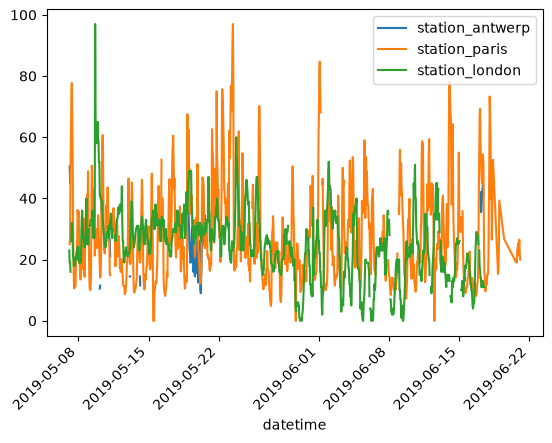

In [556]:
# How to show the graph
air_quality_review["datetime"] = pd.to_datetime(air_quality_review["datetime"])

air_quality_graph = air_quality_review.set_index("datetime").plot()
air_quality_graph.set_xlabel("datetime")

plt.xticks(rotation=45)
plt.show()

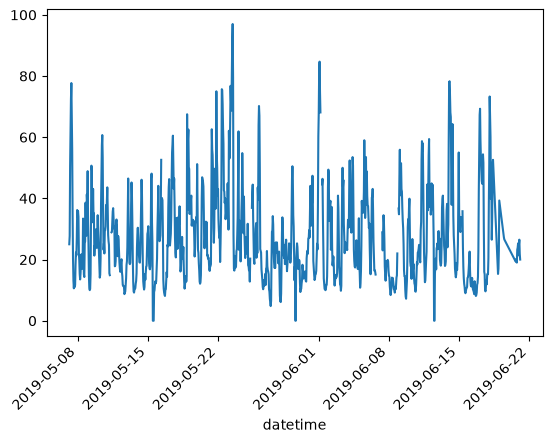

In [557]:
# How to select the graph to show

air_quality_graph = air_quality_review.set_index("datetime")["station_paris"].plot()
air_quality_graph.set_xlabel("datetime")

plt.xticks(rotation=45)
plt.show()

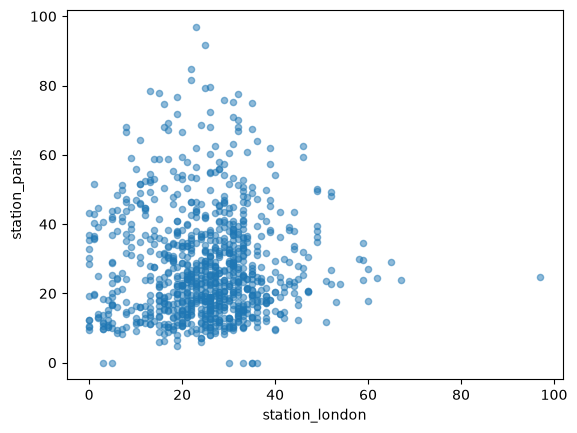

In [558]:
# How to compare two values?

air_quality_graph = air_quality_review.plot.scatter(x="station_london", y="station_paris", alpha=0.5)
air_quality_graph.set_xlabel("station_london")
air_quality_graph.set_ylabel("station_paris")

plt.show()

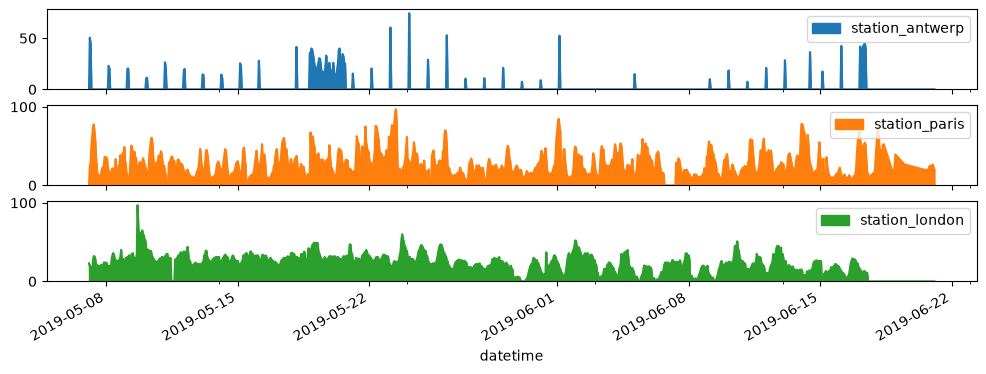

In [559]:
# How to create each columns a subplot

numeric_columns = air_quality_review.select_dtypes(include="number").columns

axs = air_quality_review.set_index("datetime")[numeric_columns].plot.area(figsize=(12, 4), subplots=True)
plt.show()

## How to create new columns derived from existing columns

In [560]:
# How to create new columns?

air_quality_review["london_mg_per_cubic"] = air_quality_review["station_london"] * 1.882
print(air_quality_review.head())

             datetime  station_antwerp  station_paris  station_london  \
0 2019-05-07 02:00:00              NaN            NaN            23.0   
1 2019-05-07 03:00:00             50.5           25.0            19.0   
2 2019-05-07 04:00:00             45.0           27.7            19.0   
3 2019-05-07 05:00:00              NaN           50.4            16.0   
4 2019-05-07 06:00:00              NaN           61.9             NaN   

   london_mg_per_cubic  
0               43.286  
1               35.758  
2               35.758  
3               30.112  
4                  NaN  


In [561]:
# How to create a new column off of two existing columns?

# Suppose that you would like to get the ratio of Antwerp and Paris
air_quality_review["ratio_paris_antwerp"] = (
  air_quality_review["station_paris"] / (air_quality_review["station_antwerp"])
)
print(air_quality_review.head())

             datetime  station_antwerp  station_paris  station_london  \
0 2019-05-07 02:00:00              NaN            NaN            23.0   
1 2019-05-07 03:00:00             50.5           25.0            19.0   
2 2019-05-07 04:00:00             45.0           27.7            19.0   
3 2019-05-07 05:00:00              NaN           50.4            16.0   
4 2019-05-07 06:00:00              NaN           61.9             NaN   

   london_mg_per_cubic  ratio_paris_antwerp  
0               43.286                  NaN  
1               35.758             0.495050  
2               35.758             0.615556  
3               30.112                  NaN  
4                  NaN                  NaN  


In [562]:
# How to rename the existing columns?

air_quality_review_renamed = air_quality_review.rename(
  columns={
    "station_antwerp": "BETR801",
    "station_paris": "FR04014",
    "station_london": "London Westminster",
  }
)
print(air_quality_review_renamed.head())

             datetime  BETR801  FR04014  London Westminster  \
0 2019-05-07 02:00:00      NaN      NaN                23.0   
1 2019-05-07 03:00:00     50.5     25.0                19.0   
2 2019-05-07 04:00:00     45.0     27.7                19.0   
3 2019-05-07 05:00:00      NaN     50.4                16.0   
4 2019-05-07 06:00:00      NaN     61.9                 NaN   

   london_mg_per_cubic  ratio_paris_antwerp  
0               43.286                  NaN  
1               35.758             0.495050  
2               35.758             0.615556  
3               30.112                  NaN  
4                  NaN                  NaN  


### REMEMBER
- Create a new column by assigning the output to the DataFrame with a new column name in between the `[]`.
- Operations are element-wise, no need to loop over rows.
- Use `rename` with a dictionary or function to rename row labels or column names.

## How to calculate summary statistics

In [563]:
# How to find the mean, median and mode of the column?

print(starbucks_review["rating"].mean())
print(starbucks_review["rating"].median())
print(starbucks_review["rating"].mode())

3.9204545454545454
4.0
0    5
Name: rating, dtype: int64


In [564]:
# How to create specific combinations of aggregating statistics

agg_air_quality = air_quality_review.agg(
  {
    "station_paris": ["min", "max", "median", "skew"],
    "station_london": ["min", "max", "median", "mean"],
  }
)
print(agg_air_quality)

        station_paris  station_london
min          0.000000         0.00000
max         97.000000        97.00000
median      24.150000        25.00000
skew         1.161128             NaN
mean              NaN        24.77709


### How to aggregate statistics and grouped them by category

In [565]:
print(titanic_data[["Sex", "Age"]].groupby("Sex").mean())

              Age
Sex              
female  27.915709
male    30.726645


### How to count the number of records by category

In [566]:
print(titanic_data["Pclass"].value_counts())

Pclass
3    491
1    216
2    184
Name: count, dtype: int64


### REMEMBER
- Aggregation statistics can be calculated on entire columns or rows.
- `groupby` provides the power of the *split-apply-combine pattern*.
- `value_counts` is a convenient shortcut to count the number of entries in each category of a variable.

## How to reshape the layout of tables

In [567]:
# How to sort the data according to the x columns
# In this case, we are going to sort the Titanic Data by the age of the passengers

print(titanic_data.sort_values(by="Age").head())

     PassengerId  Survived  Pclass                            Name     Sex  \
803          804         1       3  Thomas, Master Assad Alexander    male   
755          756         1       2        Hamalainen, Master Viljo    male   
644          645         1       3           Baclini, Miss Eugenie  female   
469          470         1       3    Baclini, Miss Helene Barbara  female   
78            79         1       2    Caldwell, Master Alden Gates    male   

      Age  SibSp  Parch  Ticket     Fare Cabin Embarked  
803  0.42      0      1    2625   8.5167   NaN        C  
755  0.67      1      1  250649  14.5000   NaN        S  
644  0.75      2      1    2666  19.2583   NaN        C  
469  0.75      2      1    2666  19.2583   NaN        C  
78   0.83      0      2  248738  29.0000   NaN        S  


In [568]:
# How to sort in descending order?
# In this case, sorting the Titanic Data by the cabin and age in descending order

print(titanic_data.sort_values(by=["Pclass", "Age"], ascending=False).head())

     PassengerId  Survived  Pclass                       Name     Sex   Age  \
851          852         0       3        Svensson, Mr. Johan    male  74.0   
116          117         0       3       Connors, Mr. Patrick    male  70.5   
280          281         0       3           Duane, Mr. Frank    male  65.0   
483          484         1       3     Turkula, Mrs. (Hedwig)  female  63.0   
326          327         0       3  Nysveen, Mr. Johan Hansen    male  61.0   

     SibSp  Parch  Ticket    Fare Cabin Embarked  
851      0      0  347060  7.7750   NaN        S  
116      0      0  370369  7.7500   NaN        Q  
280      0      0  336439  7.7500   NaN        Q  
483      0      0    4134  9.5875   NaN        S  
326      0      0  345364  6.2375   NaN        S  


### REMEMBER
- Sorting by one or more columns is supported by `sort_values`.
- The `pivot` function is purely restructuring of the data, `pivot_table` supports aggregations.
- The reverse of `pivot` (long to wide format) is `melt` (wide to long format).

## How to combine data from multiple tables

In [569]:
air_quality_pm = pd.read_csv("data/air_quality_pm25_long.csv", parse_dates=True)
air_quality_no2 = pd.read_csv("data/air_quality_no2_long.csv", parse_dates=True)

In [571]:
# How to concatenate tables?

air_quality = pd.concat([air_quality_pm, air_quality_no2], axis=0)
print(air_quality.head())

        city country                   date.utc location parameter  value  \
0  Antwerpen      BE  2019-06-18 06:00:00+00:00  BETR801      pm25   18.0   
1  Antwerpen      BE  2019-06-17 08:00:00+00:00  BETR801      pm25    6.5   
2  Antwerpen      BE  2019-06-17 07:00:00+00:00  BETR801      pm25   18.5   
3  Antwerpen      BE  2019-06-17 06:00:00+00:00  BETR801      pm25   16.0   
4  Antwerpen      BE  2019-06-17 05:00:00+00:00  BETR801      pm25    7.5   

    unit  
0  µg/m³  
1  µg/m³  
2  µg/m³  
3  µg/m³  
4  µg/m³  


### REMEMBER
- Multiple tables can be concatenated column-wise or row-wise using the `concat` function.
- For database-like merging/joining of tables, use the `merge` function.